In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import nltk
from nltk.corpus import stopwords
import re
import emoji
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
# Initialize tqdm with pandas
tqdm.pandas() # for time with pandas like progress_apply (not used in my code)


In [2]:
train_neg = pd.read_csv(
    r"C:\Users\mrtat\Downloads\DL task\dataset\train_Arabic_tweets_negative_20190413.tsv",
    sep='\t',
    encoding='utf-8'
)

train_neg.head()

,neg,اعترف ان بتس كانو شوي شوي يجيبو راسي لكن اليوم بالزايد 😭
0,neg,توقعت اذا جات داريا بشوفهم كاملين بس لي للحين ...
1,neg,#الاهلي_الهلال اكتب توقعك لنتيجة لقاء الهلال و...
2,neg,نعمة المضادات الحيوية . تضع قطرة💧مضاد بنسلين ع...
3,neg,الدودو جايه تكمل علي 💔
4,neg,أحببته حتى أقنعنى إن ما فات من العمر كان إنتظا...


In [3]:
train_pos = pd.read_csv(
    r"C:\Users\mrtat\Downloads\DL task\dataset\train_Arabic_tweets_positive_20190413.tsv",
    sep='\t',
    encoding='utf-8'
)
train_pos.head()

,pos,نحن الذين يتحول كل ما نود أن نقوله إلى دعاء لله، لا تبحثوا فينا عن قوة، إننا مكسورون، القوة التي…
0,pos,وفي النهاية لن يبقىٰ معك آحدإلا من رأىٰ الجمال...
1,pos,من الخير نفسه 💛
2,pos,#زلزل_الملعب_نصرنا_بيلعب كن عالي الهمه ولا ترض...
3,pos,الشيء الوحيد الذي وصلوا فيه للعالمية هو : المس...
4,pos,#الاتحاد_النصر لاتحسبونا نسينا يالطواقي ولانبي...


In [4]:
test_neg = pd.read_csv(
    r"C:\Users\mrtat\Downloads\DL task\dataset\test_Arabic_tweets_negative_20190413.tsv",
    sep='\t',
    encoding='utf-8'
)
test_neg.head()

,neg,حتى الايتونز خربتوه مو صاحين انتو؟؟ 😭
0,neg,واحد تبع النظام السوري يقول أن المخابرات السور...
1,neg,الى متى التعامل السئ للخادمات وعدم احترامهم وك...
2,neg,رايح جاي ي طحلبي 🐸 #الهلال_الاهلي
3,neg,تتمغط ومعها سداع 😫
4,neg,اذا ما كان ألطف كوبل مر عليكم 😭😭💛💛 حظ جانيت بس...


In [5]:
test_pos = pd.read_csv(
    r"C:\Users\mrtat\Downloads\DL task\dataset\test_Arabic_tweets_positive_20190413.tsv",
    sep='\t',
    encoding='utf-8'
)
test_pos.head()

,pos,#الهلال_الاهلي فوز هلالي مهم الحمد لله 💙 زوران كان بيسلم المباراة بعد تبديل كارييو بإنتظار الإتحاد بكرة يارب يار…
0,pos,صباحك خيرات ومسرات 🌸
1,pos,#تأمل قال الله ﷻ :- _*​﴿بواد غير ذي زرع ﴾*_ 💫💫...
2,pos,😂😂 يا جدعان الرجاله اللي فوق ال دول خطر ع تويت...
3,pos,رساله صباحيه : 💛 اللهم اسألك التوفيق في جميع ا...
4,pos,اجيال القووه والصمود والتحدي اجيال المستقبل وا...


In [6]:
# Name columns
train_pos.columns = [ 'label', 'tweet']
train_neg.columns = [ 'label', 'tweet']
test_pos.columns  = [ 'label', 'tweet']
test_neg.columns  = [ 'label', 'tweet']

In [7]:
# Merge datasets
train_df = pd.concat([train_pos, train_neg], ignore_index=True)
test_df  = pd.concat([test_pos, test_neg], ignore_index=True)


In [8]:
train_df.head()

,label,tweet
0,pos,وفي النهاية لن يبقىٰ معك آحدإلا من رأىٰ الجمال...
1,pos,من الخير نفسه 💛
2,pos,#زلزل_الملعب_نصرنا_بيلعب كن عالي الهمه ولا ترض...
3,pos,الشيء الوحيد الذي وصلوا فيه للعالمية هو : المس...
4,pos,#الاتحاد_النصر لاتحسبونا نسينا يالطواقي ولانبي...


In [9]:
test_df.head()

,label,tweet
0,pos,صباحك خيرات ومسرات 🌸
1,pos,#تأمل قال الله ﷻ :- _*​﴿بواد غير ذي زرع ﴾*_ 💫💫...
2,pos,😂😂 يا جدعان الرجاله اللي فوق ال دول خطر ع تويت...
3,pos,رساله صباحيه : 💛 اللهم اسألك التوفيق في جميع ا...
4,pos,اجيال القووه والصمود والتحدي اجيال المستقبل وا...


In [10]:
print(train_df.shape, test_df.shape)

(45273, 2) (11518, 2)


In [11]:
train_df.isnull().sum()

label    0
tweet    0
dtype: int64

In [12]:
test_df.isnull().sum()

label    0
tweet    0
dtype: int64

In [13]:
mapping = { 'pos': 1, 'neg': 0 }
train_df['label'] = train_df['label'].map(mapping)
test_df['label']  = test_df['label'].map(mapping)

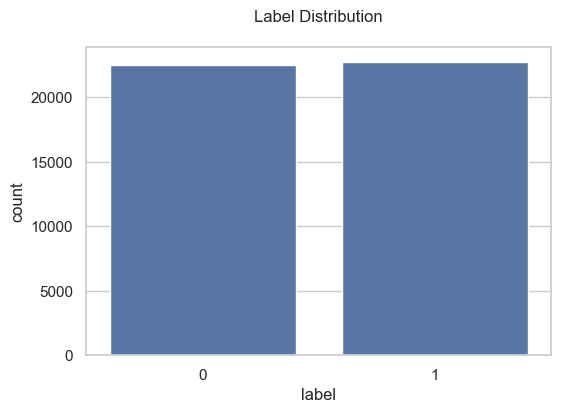

In [14]:
sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=train_df)
plt.title('Label Distribution\n')
plt.show()

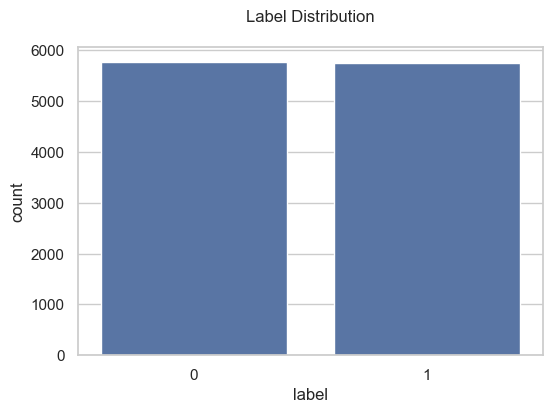

In [15]:
sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=test_df)
plt.title('Label Distribution\n')
plt.show()

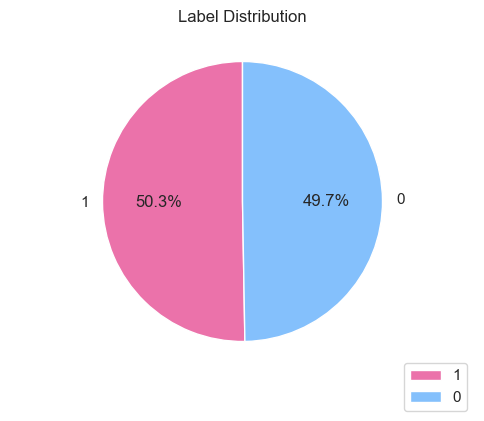

In [16]:
counts = train_df['label'].value_counts()
counts.plot(
    kind='pie',
    figsize=(6, 4),
    autopct='%1.1f%%',   # add in percentages
    startangle=90,       # start angle 90°   
    colors=["#eb72aa","#84c0fc"],  # Custom colors for the pie chart    
)

plt.title('Label Distribution\n')
plt.axis('equal')  # Sets the pie chart to look like a circle.
plt.legend(labels=counts.index, bbox_to_anchor=(1, 0))
plt.ylabel('')  # Hide y-label
plt.show()

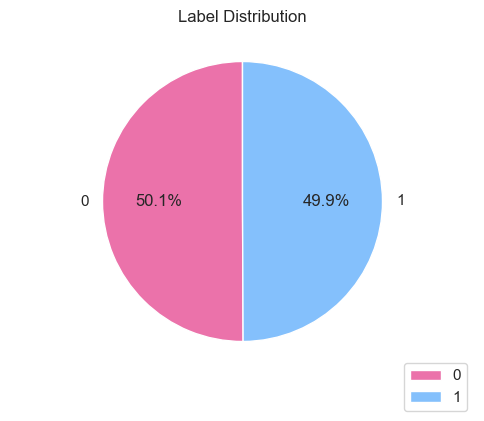

In [17]:
counts = test_df['label'].value_counts()
counts.plot(
    kind='pie',
    figsize=(6, 4),
    autopct='%1.1f%%',   # add in percentages
    startangle=90,       # start angle 90°   
    colors=["#eb72aa","#84c0fc"],  # Custom colors for the pie chart    
)

plt.title('Label Distribution\n')
plt.axis('equal')  # Sets the pie chart to look like a circle.
plt.legend(labels=counts.index, bbox_to_anchor=(1, 0))
plt.ylabel('')  # Hide y-label
plt.show()

In [18]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mrtat\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [19]:
arabic_StopWords = stopwords.words("arabic")
english_StopWords = stopwords.words("english")

In [20]:
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)  # remove HTML
    text = re.sub(r'http\S+|www.\S+', '', text)  # remove links
    text = re.sub(r'@\w+|#\w+', '', text)  # mentions & hashtags
    text = re.sub(r'[0-9٠-٩]+', '', text)  # remove digits /d from 0-9 
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)  # remove non-Arabic characters
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    text = emoji.replace_emoji(text, replace='')
    # remove stopwords
    text = " ".join([w for w in text.split() if w not in arabic_StopWords and w not in english_StopWords])
    return text

In [21]:
# apply cleaning function to tweets
train_df['tweet'] = train_df['tweet'].apply(lambda x: clean_text(x))
test_df['tweet']  = test_df['tweet'].apply(lambda x: clean_text(x))

In [22]:
train_df.head()

,label,tweet
0,1,وفي النهاية يبقىٰ معك آحدإلا رأىٰ الجمال روحك ...
1,1,الخير نفسه
2,1,عالي الهمه ترضى بغير القمه مجرد ساعات لاستعادة...
3,1,الشيء الوحيد وصلوا للعالمية المسيار ترى كانوا ...
4,1,لاتحسبونا نسينا يالطواقي ولانبيكم توقفون معنا ...


In [23]:
# features (tweets)
X_train = train_df['tweet']
X_test  = test_df['tweet']

In [24]:
#labels
y_train = train_df['label'].astype(int)
y_test  = test_df['label'].astype(int)

In [ ]:

max_words = 20000 
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")

tokenizer.fit_on_texts(X_train) 

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)


max_len = 100  
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post') #cut from the end
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post') 

print("Data shapes:", X_train_pad.shape, X_test_pad.shape)

Data shapes: (45273, 100) (11518, 100)


In [26]:
embedding_dim = 100  

model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    
    Bidirectional(SimpleRNN(64, dropout=0.5, recurrent_dropout=0.2, return_sequences=False)),
    

    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(16, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.2),
    
    Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0005), metrics=['accuracy'])

c:\Users\mrtat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [27]:
model.build(input_shape=(None, max_len))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        21,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,025,793 (7.73 MB)

 Trainable params: 2,025,793 (7.73 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:

early_stopping = EarlyStopping(
    monitor='val_loss',    # Watch the validation loss
    patience=5,            # Stop if no improvement after 5 epochs
    restore_best_weights=True, # Go back to the best model found
    verbose=1
)





history = model.fit(
    X_train_pad, y_train,
    epochs=50,             
    batch_size=64,
    validation_data=(X_test_pad, y_test),
    callbacks=[early_stopping], 
    verbose=1
)

Epoch 1/50
708/708 ━━━━━━━━━━━━━━━━━━━━ 52s 68ms/step - accuracy: 0.5041 - loss: 0.9537 - val_accuracy: 0.4993 - val_loss: 0.7326
Epoch 2/50
708/708 ━━━━━━━━━━━━━━━━━━━━ 49s 69ms/step - accuracy: 0.5183 - loss: 0.7042 - val_accuracy: 0.5253 - val_loss: 0.6940
Epoch 3/50
708/708 ━━━━━━━━━━━━━━━━━━━━ 49s 69ms/step - accuracy: 0.5678 - loss: 0.6852 - val_accuracy: 0.7157 - val_loss: 0.6005
Epoch 4/50
708/708 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.7412 - loss: 0.5433 - val_accuracy: 0.7620 - val_loss: 0.4913
Epoch 5/50
708/708 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.8226 - loss: 0.4247 - val_accuracy: 0.7625 - val_loss: 0.4849
Epoch 6/50
708/708 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.8587 - loss: 0.3617 - val_accuracy: 0.7669 - val_loss: 0.4910
Epoch 7/50
708/708 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.8782 - loss: 0.3197 - val_accuracy: 0.7658 - val_loss: 0.5164
Epoch 8/50
708/708 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.8961 - loss: 0.2870 - 

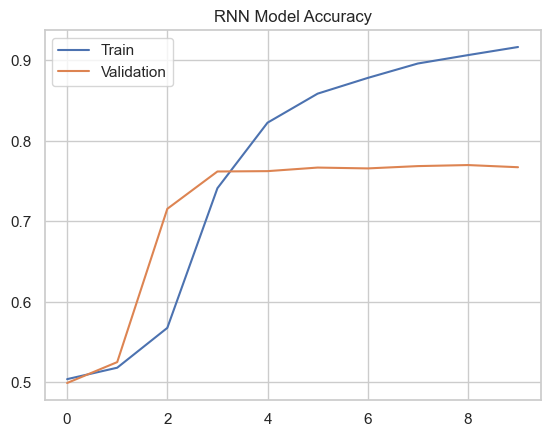

In [ ]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('RNN Model Accuracy')
plt.legend()
plt.show()